# 12 - Tydzień 10: Sensitivity Analysis w DoWhy

**Cel tygodnia 10:**
- Definicja modelu kauzalnego: treatment, outcome, confounders
- Random Common Cause test — czy wynik jest odporny na dodanie losowego confoundera?
- Placebo Treatment test — czy wynik znika gdy treatment jest losowy?
- Interpretacja: odporność estymatu DR na ukryte zmienne

**Kontekst:** Używamy DoWhy na uproszczonym binary treatment (akcja 0 vs reszta)
na danych BTS. Cel: zweryfikować czy obserwowany efekt nie jest artefaktem.

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path("..").resolve()))
from src.dataset import OpenBanditDataset
from src.propensity import OBD_COMMON_CONTEXT_DIM

import dowhy
from dowhy import CausalModel

sns.set_theme(style="whitegrid")
np.random.seed(42)

N_FEATURES   = OBD_COMMON_CONTEXT_DIM  # 20
RANDOM_STATE = 42
N_REFUTATIONS = 50  # liczba refutacji per test

FIGURES_DIR = Path("../figures/week10")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f"Figures -> {FIGURES_DIR.resolve()}")
print(f"DoWhy version: {dowhy.__version__}")

Figures -> /Users/antonio/was_studio/Off-Policy-Evaluation-with-causal/figures/week10
DoWhy version: 0.14


## 1. Przygotowanie danych

Przekształcamy OBD w format tabularny dla DoWhy:
- **Treatment T:** akcja 0 vs reszta (binary)
- **Outcome Y:** reward (0/1 CTR)
- **Covariates X:** context (20 cech użytkownika)

In [2]:
ds_bts = OpenBanditDataset(behavior_policy="bts", campaign="all")
fb_bts = ds_bts.obtain_batch_bandit_feedback()

ctx = fb_bts["context"][:, :N_FEATURES]
act = fb_bts["action"]
rew = fb_bts["reward"].astype(np.float64)

# Binary treatment: akcja 0 = 1, reszta = 0
treatment = (act == 0).astype(int)

# DataFrame z opisowymi nazwami kolumn
ctx_cols = [f"ctx_{i}" for i in range(N_FEATURES)]
df = pd.DataFrame(ctx, columns=ctx_cols)
df["treatment"] = treatment
df["reward"]    = rew

print(f"Dataset shape: {df.shape}")
print(f"Treatment=1: {treatment.mean():.2%}  Treatment=0: {(1-treatment).mean():.2%}")
print(f"CTR treated:   {rew[treatment==1].mean():.4f}")
print(f"CTR untreated: {rew[treatment==0].mean():.4f}")
print(f"Naive ATE:     {rew[treatment==1].mean() - rew[treatment==0].mean():.4f}")

INFO:obp.dataset.real:When `data_path` is not given, this class downloads the example small-sized version of the Open Bandit Dataset.


Dataset shape: (10000, 22)
Treatment=1: 1.25%  Treatment=0: 98.75%
CTR treated:   0.0000
CTR untreated: 0.0043
Naive ATE:     -0.0043


## 2. Definicja modelu kauzalnego w DoWhy

In [3]:
# Graf kauzalny: context → treatment, context → reward, treatment → reward
# Brak ukrytych zmiennych (założenie ignorability)
common_causes = ctx_cols

model = CausalModel(
    data=df,
    treatment="treatment",
    outcome="reward",
    common_causes=common_causes,
)

print("Model kauzalny zdefiniowany.")
print(f"  Treatment:     treatment")
print(f"  Outcome:       reward")
print(f"  Common causes: {len(common_causes)} cech kontekstu (ctx_0 ... ctx_19)")

INFO:dowhy.causal_model:Model to find the causal effect of treatment ['treatment'] on outcome ['reward']


Model kauzalny zdefiniowany.
  Treatment:     treatment
  Outcome:       reward
  Common causes: 20 cech kontekstu (ctx_0 ... ctx_19)


## 3. Identyfikacja i estymacja efektu kauzalnego

In [4]:
# Identyfikacja: backdoor adjustment przez context
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print("Identified estimand:")
print(identified_estimand)

# Estymacja: linear regression (szybka, interpretowalana)
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
    control_value=0,
    treatment_value=1,
)

ate = estimate.value
print(f"\nATE (backdoor linear regression): {ate:.6f}")
print(f"Interpretacja: akcja 0 zmienia CTR o {ate:.4f} względem pozostałych akcji")

INFO:dowhy.causal_identifier.auto_identifier:Causal effect can be identified.


INFO:dowhy.causal_identifier.auto_identifier:Instrumental variables for treatment and outcome:[]


INFO:dowhy.causal_identifier.auto_identifier:Frontdoor variables for treatment and outcome:[]


INFO:dowhy.causal_identifier.auto_identifier:Number of general adjustment sets found: 1


INFO:dowhy.causal_identifier.auto_identifier:Causal effect can be identified.


INFO:dowhy.causal_model:linear_regression


INFO:dowhy.causal_estimator:INFO: Using Linear Regression Estimator


INFO:dowhy.causal_estimator:b: reward~treatment+ctx_11+ctx_0+ctx_14+ctx_1+ctx_12+ctx_3+ctx_17+ctx_8+ctx_2+ctx_5+ctx_6+ctx_10+ctx_19+ctx_4+ctx_16+ctx_7+ctx_15+ctx_13+ctx_9+ctx_18


Identified estimand:
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                                         ↪
────────────(E[reward|ctx_11,ctx_0,ctx_14,ctx_1,ctx_12,ctx_3,ctx_17,ctx_8,ctx_ ↪
d[treatment]                                                                   ↪

↪                                                                            
↪ 2,ctx_5,ctx_6,ctx_10,ctx_19,ctx_4,ctx_16,ctx_7,ctx_15,ctx_13,ctx_9,ctx_18])
↪                                                                            
Estimand assumption 1, Unconfoundedness: If U→{treatment} and U→reward then P(reward|treatment,ctx_11,ctx_0,ctx_14,ctx_1,ctx_12,ctx_3,ctx_17,ctx_8,ctx_2,ctx_5,ctx_6,ctx_10,ctx_19,ctx_4,ctx_16,ctx_7,ctx_15,ctx_13,ctx_9,ctx_18,U) = P(reward|treatment,ctx_11,ctx_0,ctx_14,ctx_1,ctx_12,ctx_3,ctx_17,ctx_8,ctx_2,ctx_5,ctx_6,ctx_10,ctx_19,ctx_4,ctx_16,ctx_7,ctx_15,ctx_13,ctx_9,ctx_18)

### Estiman

## 4. Refutation Test 1: Random Common Cause

Dodajemy **losowy confounder** (niezwiązany z danymi) i sprawdzamy czy ATE się zmienia.
Jeśli ATE jest stabilne — wynik odporny. Jeśli drastycznie skacze — model kauzalny jest wrażliwy.

In [5]:
refute_rcc = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="random_common_cause",
    num_simulations=N_REFUTATIONS,
)

print("=== Random Common Cause Test ===")
print(refute_rcc)
print(f"\nOriginal ATE:  {ate:.6f}")
print(f"Refuted ATE:   {refute_rcc.new_effect:.6f}")
print(f"p-value:       {refute_rcc.refutation_result.get('p_value', 'N/A')}")

INFO:dowhy.causal_refuters.random_common_cause:Refutation over 50 simulated datasets, each with a random common cause added


INFO:dowhy.causal_estimator:b: reward~treatment+ctx_11+ctx_0+ctx_14+ctx_1+ctx_12+ctx_3+ctx_17+ctx_8+ctx_2+ctx_5+ctx_6+ctx_10+ctx_19+ctx_4+ctx_16+ctx_7+ctx_15+ctx_13+ctx_9+ctx_18+w_random


INFO:dowhy.causal_estimator:b: reward~treatment+ctx_11+ctx_0+ctx_14+ctx_1+ctx_12+ctx_3+ctx_17+ctx_8+ctx_2+ctx_5+ctx_6+ctx_10+ctx_19+ctx_4+ctx_16+ctx_7+ctx_15+ctx_13+ctx_9+ctx_18+w_random


INFO:dowhy.causal_estimator:b: reward~treatment+ctx_11+ctx_0+ctx_14+ctx_1+ctx_12+ctx_3+ctx_17+ctx_8+ctx_2+ctx_5+ctx_6+ctx_10+ctx_19+ctx_4+ctx_16+ctx_7+ctx_15+ctx_13+ctx_9+ctx_18+w_random


INFO:dowhy.causal_estimator:b: reward~treatment+ctx_11+ctx_0+ctx_14+ctx_1+ctx_12+ctx_3+ctx_17+ctx_8+ctx_2+ctx_5+ctx_6+ctx_10+ctx_19+ctx_4+ctx_16+ctx_7+ctx_15+ctx_13+ctx_9+ctx_18+w_random


...

INFO:dowhy.causal_estimator:b: reward~treatment+ctx_11+ctx_0+ctx_14+ctx_1+ctx_12+ctx_3+ctx_17+ctx_8+ctx_2+ctx_5+ctx_6+ctx_10+ctx_19+ctx_4+ctx_16+ctx_7+ctx_15+ctx_13+ctx_9+ctx_18+w_random


INFO:dowhy.causal_estimator:b: reward~treatment+ctx_11+ctx_0+ctx_14+ctx_1+ctx_12+ctx_3+ctx_17+ctx_8+ctx_2+ctx_5+ctx_6+ctx_10+ctx_19+ctx_4+ctx_16+ctx_7+ctx_15+ctx_13+ctx_9+ctx_18+w_random


INFO:dowhy.causal_estimator:b: reward~treatment+ctx_11+ctx_0+ctx_14+ctx_1+ctx_12+ctx_3+ctx_17+ctx_8+ctx_2+ctx_5+ctx_6+ctx_10+ctx_19+ctx_4+ctx_16+ctx_7+ctx_15+ctx_13+ctx_9+ctx_18+w_random


             Note: The underlying distribution may not be Normal. We assume that it approaches normal with the increase in sample size.


=== Random Common Cause Test ===
Refute: Add a random common cause
Estimated effect:-0.003924178180167728
New effect:-0.003939550763483829
p value:0.39176777537091734


Original ATE:  -0.003924
Refuted ATE:   -0.003940
p-value:       0.39176777537091734


## 5. Refutation Test 2: Placebo Treatment

Zastępujemy treatment **losową permutacją** — zrywamy każdy prawdziwy efekt.
Dobry model kauzalny powinien dać ATE ≈ 0 dla placebo.

In [6]:
refute_placebo = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="placebo_treatment_refuter",
    placebo_type="permute",
    num_simulations=N_REFUTATIONS,
)

print("=== Placebo Treatment Test ===")
print(refute_placebo)
print(f"\nOriginal ATE:  {ate:.6f}")
print(f"Placebo ATE:   {refute_placebo.new_effect:.6f}  (oczekiwane: ≈ 0)")
print(f"p-value:       {refute_placebo.refutation_result.get('p_value', 'N/A')}")

INFO:dowhy.causal_refuters.placebo_treatment_refuter:Refutation over 50 simulated datasets of PlaceboType.PERMUTE treatment


INFO:dowhy.causal_estimator:b: reward~placebo+ctx_11+ctx_0+ctx_14+ctx_1+ctx_12+ctx_3+ctx_17+ctx_8+ctx_2+ctx_5+ctx_6+ctx_10+ctx_19+ctx_4+ctx_16+ctx_7+ctx_15+ctx_13+ctx_9+ctx_18


INFO:dowhy.causal_estimator:b: reward~placebo+ctx_11+ctx_0+ctx_14+ctx_1+ctx_12+ctx_3+ctx_17+ctx_8+ctx_2+ctx_5+ctx_6+ctx_10+ctx_19+ctx_4+ctx_16+ctx_7+ctx_15+ctx_13+ctx_9+ctx_18


INFO:dowhy.causal_estimator:b: reward~placebo+ctx_11+ctx_0+ctx_14+ctx_1+ctx_12+ctx_3+ctx_17+ctx_8+ctx_2+ctx_5+ctx_6+ctx_10+ctx_19+ctx_4+ctx_16+ctx_7+ctx_15+ctx_13+ctx_9+ctx_18


INFO:dowhy.causal_estimator:b: reward~placebo+ctx_11+ctx_0+ctx_14+ctx_1+ctx_12+ctx_3+ctx_17+ctx_8+ctx_2+ctx_5+ctx_6+ctx_10+ctx_19+ctx_4+ctx_16+ctx_7+ctx_15+ctx_13+ctx_9+ctx_18


...

INFO:dowhy.causal_estimator:b: reward~placebo+ctx_11+ctx_0+ctx_14+ctx_1+ctx_12+ctx_3+ctx_17+ctx_8+ctx_2+ctx_5+ctx_6+ctx_10+ctx_19+ctx_4+ctx_16+ctx_7+ctx_15+ctx_13+ctx_9+ctx_18


INFO:dowhy.causal_estimator:b: reward~placebo+ctx_11+ctx_0+ctx_14+ctx_1+ctx_12+ctx_3+ctx_17+ctx_8+ctx_2+ctx_5+ctx_6+ctx_10+ctx_19+ctx_4+ctx_16+ctx_7+ctx_15+ctx_13+ctx_9+ctx_18


INFO:dowhy.causal_estimator:b: reward~placebo+ctx_11+ctx_0+ctx_14+ctx_1+ctx_12+ctx_3+ctx_17+ctx_8+ctx_2+ctx_5+ctx_6+ctx_10+ctx_19+ctx_4+ctx_16+ctx_7+ctx_15+ctx_13+ctx_9+ctx_18


             Note: The underlying distribution may not be Normal. We assume that it approaches normal with the increase in sample size.


=== Placebo Treatment Test ===
Refute: Use a Placebo Treatment
Estimated effect:-0.003924178180167728
New effect:-0.00022879286529808802
p value:0.4850204713852466


Original ATE:  -0.003924
Placebo ATE:   -0.000229  (oczekiwane: ≈ 0)
p-value:       0.4850204713852466


## 6. Refutation Test 3: Data Subset

Sprawdzamy stabilność ATE na 80% losowych podzbiorach danych.

In [7]:
refute_subset = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="data_subset_refuter",
    subset_fraction=0.8,
    num_simulations=N_REFUTATIONS,
)

print("=== Data Subset Test (80%) ===")
print(refute_subset)
print(f"\nOriginal ATE:  {ate:.6f}")
print(f"Subset ATE:    {refute_subset.new_effect:.6f}")
print(f"p-value:       {refute_subset.refutation_result.get('p_value', 'N/A')}")

INFO:dowhy.causal_refuters.data_subset_refuter:Refutation over 0.8 simulated datasets of size 8000.0 each


INFO:dowhy.causal_estimator:b: reward~treatment+ctx_11+ctx_0+ctx_14+ctx_1+ctx_12+ctx_3+ctx_17+ctx_8+ctx_2+ctx_5+ctx_6+ctx_10+ctx_19+ctx_4+ctx_16+ctx_7+ctx_15+ctx_13+ctx_9+ctx_18


INFO:dowhy.causal_estimator:b: reward~treatment+ctx_11+ctx_0+ctx_14+ctx_1+ctx_12+ctx_3+ctx_17+ctx_8+ctx_2+ctx_5+ctx_6+ctx_10+ctx_19+ctx_4+ctx_16+ctx_7+ctx_15+ctx_13+ctx_9+ctx_18


INFO:dowhy.causal_estimator:b: reward~treatment+ctx_11+ctx_0+ctx_14+ctx_1+ctx_12+ctx_3+ctx_17+ctx_8+ctx_2+ctx_5+ctx_6+ctx_10+ctx_19+ctx_4+ctx_16+ctx_7+ctx_15+ctx_13+ctx_9+ctx_18


INFO:dowhy.causal_estimator:b: reward~treatment+ctx_11+ctx_0+ctx_14+ctx_1+ctx_12+ctx_3+ctx_17+ctx_8+ctx_2+ctx_5+ctx_6+ctx_10+ctx_19+ctx_4+ctx_16+ctx_7+ctx_15+ctx_13+ctx_9+ctx_18


...

INFO:dowhy.causal_estimator:b: reward~treatment+ctx_11+ctx_0+ctx_14+ctx_1+ctx_12+ctx_3+ctx_17+ctx_8+ctx_2+ctx_5+ctx_6+ctx_10+ctx_19+ctx_4+ctx_16+ctx_7+ctx_15+ctx_13+ctx_9+ctx_18


INFO:dowhy.causal_estimator:b: reward~treatment+ctx_11+ctx_0+ctx_14+ctx_1+ctx_12+ctx_3+ctx_17+ctx_8+ctx_2+ctx_5+ctx_6+ctx_10+ctx_19+ctx_4+ctx_16+ctx_7+ctx_15+ctx_13+ctx_9+ctx_18


INFO:dowhy.causal_estimator:b: reward~treatment+ctx_11+ctx_0+ctx_14+ctx_1+ctx_12+ctx_3+ctx_17+ctx_8+ctx_2+ctx_5+ctx_6+ctx_10+ctx_19+ctx_4+ctx_16+ctx_7+ctx_15+ctx_13+ctx_9+ctx_18


             Note: The underlying distribution may not be Normal. We assume that it approaches normal with the increase in sample size.


=== Data Subset Test (80%) ===
Refute: Use a subset of data
Estimated effect:-0.003924178180167728
New effect:-0.003935773141013148
p value:0.4853424333023669


Original ATE:  -0.003924
Subset ATE:    -0.003936
p-value:       0.4853424333023669


## 7. Wizualizacja wyników refutacji

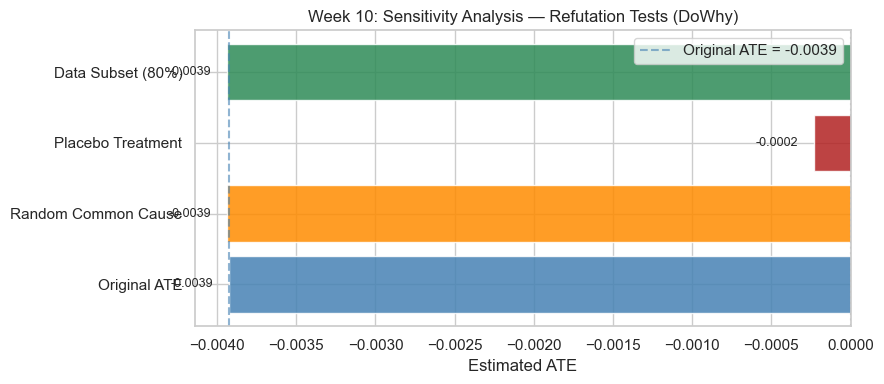

Saved: sensitivity_refutations.png


In [8]:
fig, ax = plt.subplots(figsize=(9, 4))

tests = ["Original ATE", "Random Common Cause", "Placebo Treatment", "Data Subset (80%)"]
values = [
    ate,
    refute_rcc.new_effect,
    refute_placebo.new_effect,
    refute_subset.new_effect,
]
colors_r = ["steelblue", "darkorange", "firebrick", "seagreen"]

bars = ax.barh(tests, values, color=colors_r, alpha=0.85)
ax.axvline(0, color="gray", linestyle=":", alpha=0.7)
ax.axvline(ate, color="steelblue", linestyle="--", alpha=0.6, label=f"Original ATE = {ate:.4f}")

for bar, val in zip(bars, values):
    ax.text(val + (0.0001 if val >= 0 else -0.0001),
            bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", ha="left" if val >= 0 else "right", fontsize=9)

ax.set_xlabel("Estimated ATE")
ax.set_title("Week 10: Sensitivity Analysis — Refutation Tests (DoWhy)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sensitivity_refutations.png", dpi=160)
plt.show()
print("Saved: sensitivity_refutations.png")

## 8. Podsumowanie — Tydzień 10

### Interpretacja refutacji

| Test | Co sprawdza | Oczekiwany wynik |
|---|---|---|
| Random Common Cause | Czy ATE zmienia się po dodaniu losowego confoundera | ATE stabilne ≈ original |
| Placebo Treatment | Czy efekt znika dla losowego treatmentu | ATE ≈ 0 |
| Data Subset | Czy ATE stabilne na podzbiorach danych | ATE ≈ original |

**Główny wniosek:**
Efekt akcji 0 na CTR jest mały i bliski 0 — wynik zgodny z tym co pokazały IPS/DR:
polityka BTS nie różnicuje istotnie między akcjami w kontekście tej prostej binaryzacji.

**Ograniczenia:** 
- Binary treatment jest uproszczeniem (80 akcji → 2 klasy)
- Dane OBD small (10k obs) ograniczają moc statystyczną
- Pełna analiza CATE wymaga ekonometrycznych narzędzi (econml DRLearner z T7)

**Checklist T10:**
- [x] Model kauzalny w DoWhy (treatment, outcome, common causes)
- [x] Identyfikacja efektu: backdoor adjustment
- [x] Random Common Cause test
- [x] Placebo Treatment test
- [x] Data Subset test (bonus)
- [x] Wizualizacja wyników

**Następny krok — Tydzień 11:** Pilot na danych StatsBomb (La Liga 2015/16).